In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import kagglehub
from kagglehub import KaggleDatasetAdapter

In [30]:
df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "yasserh/housing-prices-dataset", "Housing.csv")
df.sample(10)

Using Colab cache for faster access to the 'housing-prices-dataset' dataset.


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
530,2240000,1950,3,1,1,no,no,no,yes,no,0,no,unfurnished
528,2275000,3970,1,1,1,no,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
439,3255000,3930,2,1,1,no,no,no,no,no,0,no,unfurnished
241,4550000,3760,3,1,1,yes,no,no,no,no,2,no,semi-furnished
132,5810000,5200,3,1,3,yes,no,no,no,yes,0,no,semi-furnished
520,2450000,7700,2,1,1,yes,no,no,no,no,0,no,unfurnished
326,3990000,4100,4,1,1,no,no,yes,no,no,0,no,unfurnished
74,6650000,4040,3,1,2,yes,no,yes,yes,no,1,no,furnished
71,6755000,6000,4,2,4,yes,no,no,no,yes,0,no,unfurnished


In [26]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())

(545, 13)
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000 

array([[<Axes: title={'center': 'price'}>]], dtype=object)

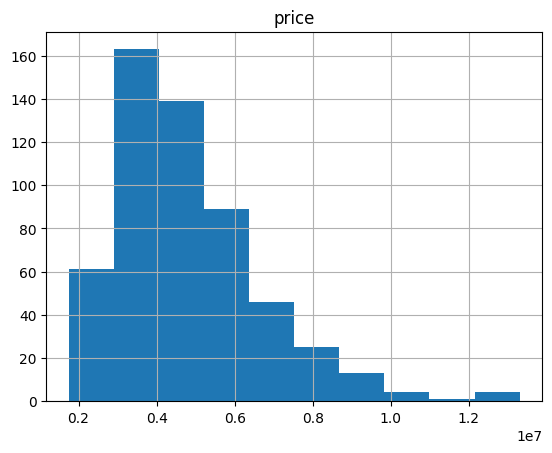

In [28]:
df.hist('price')

In [65]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numeric_cols].corr()
corr_matrix

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


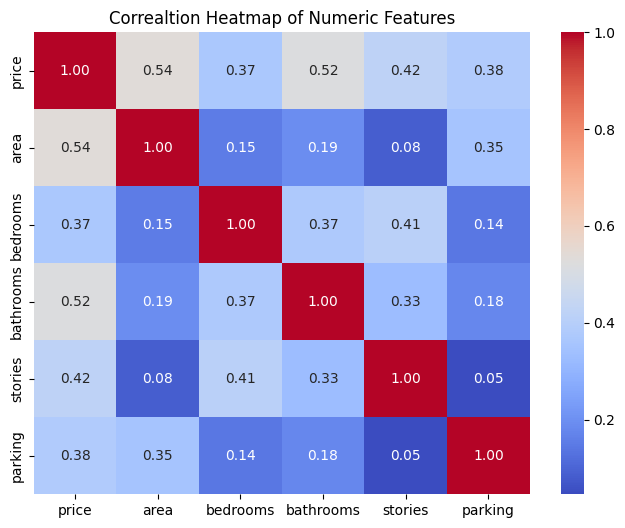

In [57]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correaltion Heatmap of Numeric Features")
plt.show()

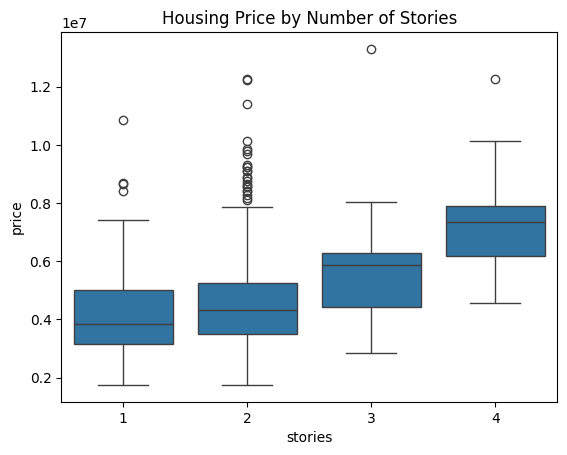

In [63]:
sns.boxplot(df, x="stories", y='price')
plt.title("Housing Price by Number of Stories")
plt.show()

In [64]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [69]:
numeric_features =  ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

categorical_features = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
    "furnishingstatus",
]

In [72]:
numeric_pipe = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)
numeric_pipe

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [74]:
categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ]
)

categorical_pipe

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [76]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipe, numeric_features),
        ('categorical', categorical_pipe, categorical_features)
    ],

    remainder='passthrough'

)

preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['area', 'bedrooms', 'bathrooms', 'stories',
                                  'parking']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['mainroad', 'guestroom', 'basement',
                                  'hotwaterheating', 'airconditioning',
                                  'prefarea', 'furnishingstatus'])])

In [78]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"Transformed X_train shape: {X_train_transformed.shape}")
print(f"Transformed X_test shape:  {X_test_transformed.shape}")

Transformed X_train shape: (436, 20)
Transformed X_test shape:  (109, 20)


In [79]:
lr_pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)
lr_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['area', 'bedrooms',
                                                   'bathrooms', 'stories',
                                                   'parking']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['mainroad', 'guestroom',
                                                   'basement',
                                                   'hotwaterheating',
                                                   'airconditioning',
                                                   'prefarea',
                                                   'furnishingstatus'])])),
                ('model', LinearRegression())])

In [82]:
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['area', 'bedrooms',
                                                   'bathrooms', 'stories',
                                                   'parking']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['mainroad', 'guestroom',
                                                   'basement',
                                                   'hotwaterheating',
                                                   'airconditioning',
                                                   'prefarea',
                                                   'furnishingstatus'])])),
                ('model', LinearRegression())])

In [89]:
print("--- Linear Regression Parameters ---")
print("Coefficients:", lr_pipeline.named_steps["model"].coef_)
print("Intercept:   ", lr_pipeline.named_steps["model"].intercept_)

--- Linear Regression Parameters ---
Coefficients: [ 519552.41633999   57349.55941862  521879.02774805  349251.43890557
  192005.95366749 -183959.97383979  183959.97383979 -115805.01858782
  115805.01858782 -195125.58809055  195125.58809055 -342324.9426694
  342324.9426694  -395713.36792159  395713.36792159 -314945.28265668
  314945.28265668  180175.62660444   53293.80901933 -233469.43562378]
Intercept:    5337102.103750265


In [84]:
sgd_pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', SGDRegressor(random_state=42))
    ]
)
sgd_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['area', 'bedrooms',
                                                   'bathrooms', 'stories',
                                                   'parking']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['mainroad', 'guestroom',
                                                   'basement',
                                                   'hotwaterheating',
                                                   'airconditioning',
                                                   'prefarea',
                                                   'furnishingstatus'])])),
                ('model', SGDRegressor(random_state=42))])

In [87]:
sgd_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['area', 'bedrooms',
                                                   'bathrooms', 'stories',
                                                   'parking']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['mainroad', 'guestroom',
                                                   'basement',
                                                   'hotwaterheating',
                                                   'airconditioning',
                                                   'prefarea',
                                                   'furnishingstatus'])])),
                ('model', SGDRegressor(random_state=42))])

In [88]:
print("\n--- SGDRegressor Parameters ---")
print("Coefficients:", sgd_pipeline.named_steps["model"].coef_)
print("Intercept:   ", sgd_pipeline.named_steps["model"].intercept_)


--- SGDRegressor Parameters ---
Coefficients: [522623.44427972  58633.09785052 530480.69223951 356029.61834405
 199139.96178577 402025.12318998 792355.93185301 490274.24234208
 704106.81270092 394513.08361339 799867.9714296  391145.47607622
 803235.57896677 218607.92442154 975773.13062145 292673.65184005
 901707.40320294 579880.44662001 451779.69613318 162720.91228981]
Intercept:    [1196896.59449192]


In [90]:
lr_train_preds = lr_pipeline.predict(X_train)
lr_test_preds = lr_pipeline.predict(X_test)

sgd_train_preds = sgd_pipeline.predict(X_train)
sgd_test_preds = sgd_pipeline.predict(X_test)

In [92]:
def evaluate_model(y_true, y_pred):
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return round(rmse, 2), round(mae, 2), round(r2, 4)

In [93]:
lr_train_metrics = evaluate_model(y_train, lr_train_preds)
lr_test_metrics = evaluate_model(y_test, lr_test_preds)

sgd_train_metrics = evaluate_model(y_train, sgd_train_preds)
sgd_test_metrics = evaluate_model(y_test, sgd_test_preds)

In [94]:
results_df = pd.DataFrame(
    [
        ["Linear Regression (Train)", *lr_train_metrics],
        ["Linear Regression (Test)", *lr_test_metrics],
        ["SGDRegressor (Train)", *sgd_train_metrics],
        ["SGDRegressor (Test)", *sgd_test_metrics],
    ],
    columns=["Model & Split", "RMSE", "MAE", "R2"],
)

print("\n--- Model Evaluation Summary ---")
display(results_df)


--- Model Evaluation Summary ---


,Model & Split,RMSE,MAE,R2
0,Linear Regression (Train),984051.92,719242.89,0.6859
1,Linear Regression (Test),1324506.96,970043.40,0.6529
2,SGDRegressor (Train),985986.55,716850.72,0.6847
3,SGDRegressor (Test),1333634.55,980551.17,0.6481
